# Disaster-FCV Scan Tutorial

## Imports and Setup

In [1]:
import re
import os
import pprint
os.chdir("..")

from osgeo import gdal
from src.dfcv_colocation_mapping import data_download
from src.dfcv_colocation_mapping import common_utils
from src.dfcv_colocation_mapping import map_utils
from src.dfcv_colocation_mapping import widgets

import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

%load_ext autoreload
%autoreload 2

<a name="download-data"></a>
# Download Data

In [12]:
# Country name and admin Level
iso_code = "NPL" 
iso_code = re.sub(r'\([^)]*\)', '', iso_code).strip()
adm_level = "ADM3" 

# Conflict start and end dates
conflict_start_date = "2020-01-01" 
conflict_end_date = date.today()

# Displacement start and end years
displacement_start_year = 2020
displacement_end_year = 2025 

config_file = "src/dfcv_colocation_mapping/configs/data_config.yaml"
acled_cred_file = "creds/acled_creds.yaml"
dtm_cred_file = "creds/dtm_creds.yaml"
idmc_cred_file = "creds/idmc_creds.yaml"
adm_config_file = "src/dfcv_colocation_mapping/configs/adm_config.yaml"
osm_config_file = "src/dfcv_colocation_mapping/configs/osm_config.yaml"
acled_config_file = "src/dfcv_colocation_mapping/configs/acled_config.yaml"

dm = data_download.DatasetManager(
    iso_code, 
    adm_level=adm_level,
    config_file=config_file,
    acled_cred_file=acled_cred_file,
    dtm_cred_file=dtm_cred_file,
    idmc_cred_file=idmc_cred_file,
    adm_config_file=adm_config_file,
    osm_config_file=osm_config_file,
    acled_config_file=acled_config_file,
    conflict_start_date=conflict_start_date,
    displacement_start_year=displacement_start_year,
    displacement_end_year=displacement_end_year
)

## Optional: Filter Datasets

In [13]:
data_category = "osm" # Choose from: "assets", "hazards", "conflict", "displacement", "osm"

def save_selection(result):
    dm.config[f"{data_category}_selected"] = result
    dm.set_selected_datasets()

selector = widgets.MultiSelector(
    data_category,
    dm.config[f"{data_category}_all"],
    dm.config[f"{data_category}_selected"],
    save_callback=save_selection
)
selector.show()

## Optional: Filter ACLED Categories

In [5]:
drm_pillar = "risk_reduction"
asset_category = "housing" 

dm.update_acled_selected(drm_pillar)
def save_selection(result):
    dm.acled_selected[asset_category] = result

selector = widgets.HierarchicalSelector(
    asset_category,
    hierarchy=dm.acled_hierarchy,
    selected=dm.acled_selected[asset_category],
    save_callback=save_selection,
    save_label="Save ACLED Selection"
)
selector.show()

## Download Datasets

In [16]:
%%time
dm.download_datasets()
geoplot = map_utils.GeoPlot(dm,  map_config_file="src/dfcv_colocation_mapping/configs/map_config.yaml")
dm.data.head(3)

INFO:root:Loading ADM3 geoboundaries...
INFO:root:Loading Asset Layers...
INFO:root:Loading Hazard Layers...
INFO:root:Loading ACLED data...
Processing worldpop: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.67s/it]
INFO:root:Loading IOM DTM data...
INFO:root:WARNING: Network connection to dtm.iom.int could not be established.
INFO:root:Loading IDMC GIDD data...
INFO:root:WARNING: No IDMC Conflict data for Nepal.
INFO:root:Loading UNHCR data...
INFO:root:Calculating multihazard scores...


CPU times: total: 39.6 s
Wall time: 1min 3s


,iso_code,ADM3,ADM3_ID,ADM2_ID,ADM2,ADM1_ID,ADM1,geometry,worldpop,earthquake,earthquake_worldpop_exposure_absolute,earthquake_worldpop_intensity_weighted_exposure_absolute,landslide_earthquake_gfdrr,landslide_earthquake_gfdrr_worldpop_exposure_absolute,landslide_earthquake_gfdrr_worldpop_intensity_weighted_exposure_absolute,landslide_precip_gfdrr,landslide_precip_gfdrr_worldpop_exposure_absolute,landslide_precip_gfdrr_worldpop_intensity_weighted_exposure_absolute,cyclone,cyclone_worldpop_exposure_absolute,cyclone_worldpop_intensity_weighted_exposure_absolute,drought_spei,drought_spei_worldpop_exposure_absolute,drought_spei_worldpop_intensity_weighted_exposure_absolute,heat_stress,heat_stress_worldpop_exposure_absolute,heat_stress_worldpop_intensity_weighted_exposure_absolute,wildfire_geos5,wildfire_geos5_worldpop_exposure_absolute,wildfire_geos5_worldpop_intensity_weighted_exposure_absolute,fluvial_flood_cdri,fluvial_flood_cdri_worldpop_exposure_absolute,fluvial_flood_cdri_worldpop_intensity_weighted_exposure_absolute,acled_worldpop_conflict_count,acled_worldpop_fatalities,acled_worldpop_fatalities_per_conflict,wbg_acled_worldpop_exposure_absolute,idmc_disaster_idp_total_2023,idmc_disaster_idp_total_2024,idmc_idp_total_2020,idmc_idp_total_2021,idmc_idp_total_2022,idmc_idp_total_2023,idmc_idp_total_2024,idmc_idp_total_2025,idmc_idp_mean,earthquake_worldpop_exposure_relative,earthquake_worldpop_intensity_weighted_exposure_relative,landslide_earthquake_gfdrr_worldpop_exposure_relative,landslide_earthquake_gfdrr_worldpop_intensity_weighted_exposure_relative,landslide_precip_gfdrr_worldpop_exposure_relative,landslide_precip_gfdrr_worldpop_intensity_weighted_exposure_relative,cyclone_worldpop_exposure_relative,cyclone_worldpop_intensity_weighted_exposure_relative,drought_spei_worldpop_exposure_relative,drought_spei_worldpop_intensity_weighted_exposure_relative,heat_stress_worldpop_exposure_relative,heat_stress_worldpop_intensity_weighted_exposure_relative,wildfire_geos5_worldpop_exposure_relative,wildfire_geos5_worldpop_intensity_weighted_exposure_relative,fluvial_flood_cdri_worldpop_exposure_relative,fluvial_flood_cdri_worldpop_intensity_weighted_exposure_relative,wbg_acled_worldpop_exposure_relative,mhs_all_worldpop_exposure_absolute,mhs_all_wbg_acled_worldpop_exposure_absolute,mhs_all_worldpop_exposure_relative,mhs_all_wbg_acled_worldpop_exposure_relative,mhs_all_worldpop_intensity_weighted_exposure_relative
0,NPL,Aathrai Tribeni,92635248B35930527562565,16334872B19913748765836,Aathrai Tribeni,65065323B98036321283204,Province 1,"POLYGON ((87.62458 27.36214, 87.62417 27.36218...",9727.937500,0.409878,9727.937500,7650.241211,0.007682,9727.937500,745.938477,0.016530,9727.937500,2692.576416,0.0,0.0,0.0,0.174503,0.0,0.0,2085.119048,0.0,0.0,13.667601,9727.937500,1449.223633,748.290909,231.822662,24.339870,1.0,0.0,0.0,2741.256836,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.786420,1.0,0.076680,1.000000,0.276788,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.148975,0.023831,0.002502,0.281792,0.004541,4.329955e-06,0.662157,0.186539,0.355322
1,NPL,Maiwakhola,92635248B59073504839030,16334872B84565050443233,Maiwakhola,65065323B98036321283204,Province 1,"POLYGON ((87.60866 27.37094, 87.60816 27.37131...",6856.546875,0.410999,6856.546875,5409.578125,0.018897,6856.546875,1037.569336,0.017583,6856.546875,1874.844849,0.0,0.0,0.0,0.144083,0.0,0.0,1708.025000,0.0,0.0,9.514197,4902.930664,763.423462,0.000000,0.000000,0.000000,NaN,NaN,NaN,14.975756,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.788965,1.0,0.151325,1.000000,0.273439,0.0,0.0,0.0,0.0,0.0,0.0,0.715073,0.111342,0.000000,0.000000,0.002184,0.002955,1.472402e-08,0.561138,0.001165,0.374452
2,NPL,Meringden,92635248B29608067075371,16334872B41692261676070,Meringden,65065323B98036321283204,Province 1,"POLYGON ((87.62458 27.36214, 87.62544 27.36337...",8625.122070,0.416600,8625.122070,6941.916016,0.020388,8625.122070,1220.405884,0.016985,8613.430664,2735.520996,0.0,0.0,0.0,0.271280,0.0,0.0,1657.795139,0.0,0.0,9.51419

<a name="administrative-boundaries"></a>
# Administrative Boundaries

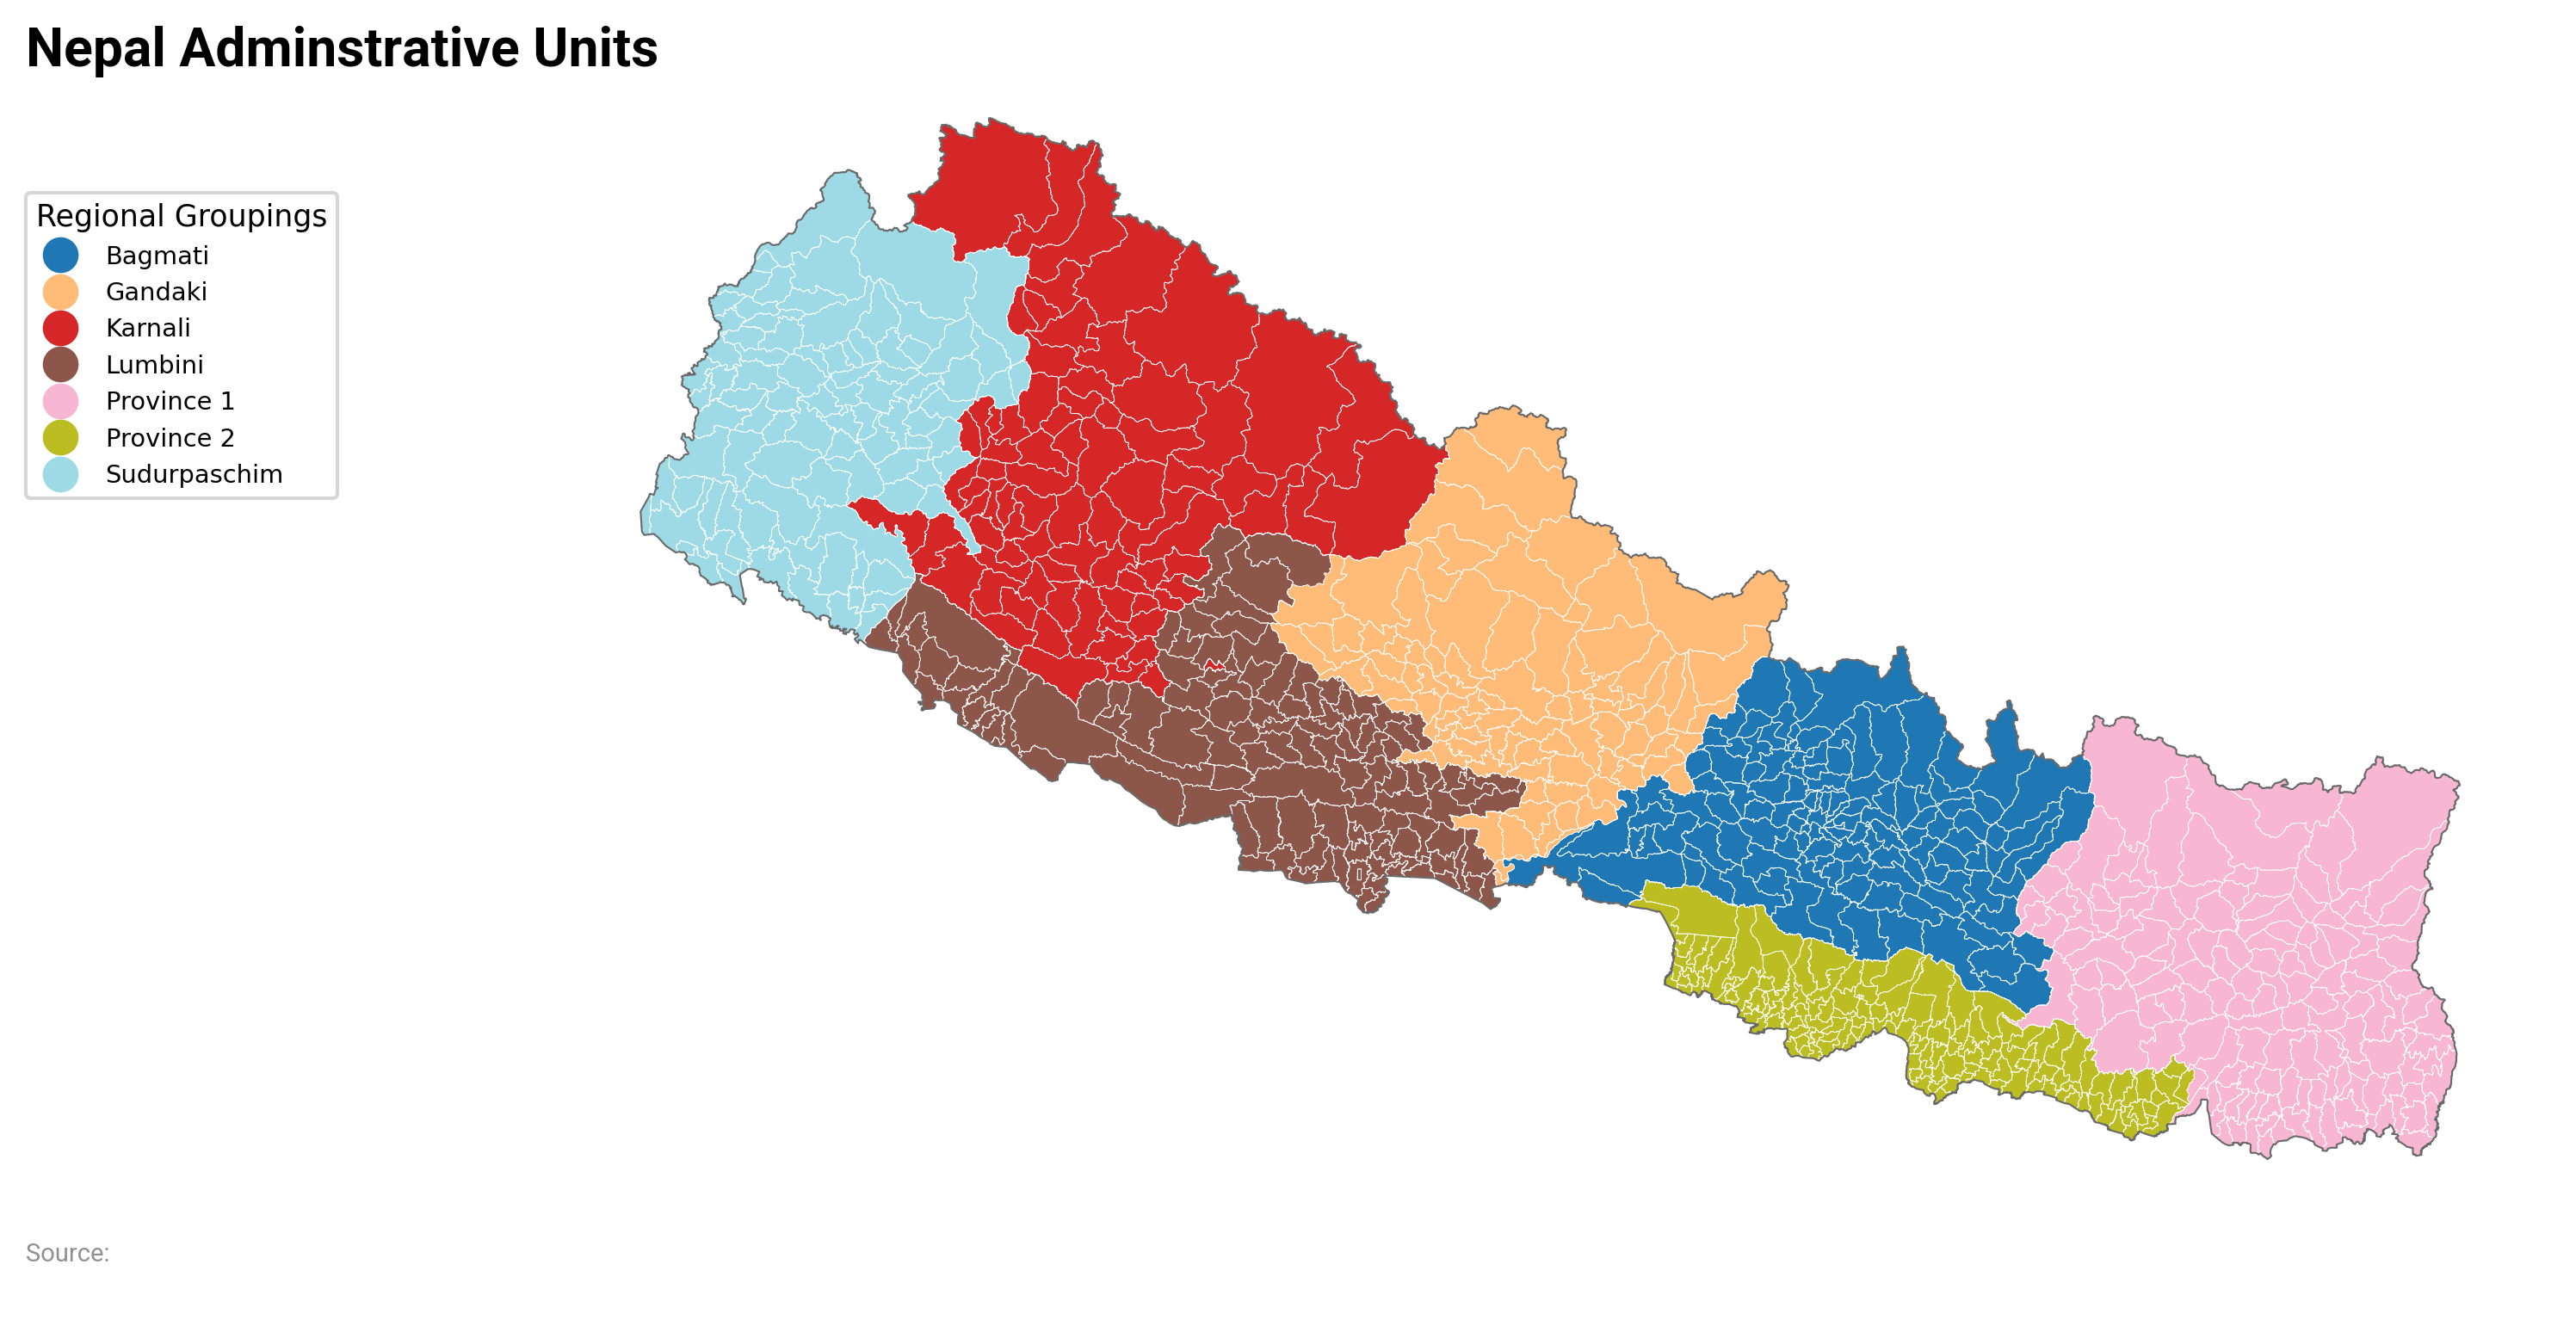

In [6]:
group = "ADM1" 
adm_level = "ADM2" 

geoplot.plot_geoboundaries(
    adm_level=adm_level,
    group=group,
    save=True
);

<a name="asset-data-layers"></a>
# Asset Data Layers

In [7]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    var_list=dm.asset_names,
    var_label="Asset",
    out_dir="assets"
)
widget.show()

Output()

<a name="internal-displacement-data-layers"></a>
# Displacement Data Layers

In [8]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_displacement=True,
    plot_osm_networks=True,
    plot_osm_points=True,
    out_dir="displacement"
)
widget.show()

Output()

<a name="conflict-data-layers"></a>
# Conflict Data Layers

In [34]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_conflict=True,
    plot_conflict_points=True,
    zoom_to_region=True,
    out_dir="conflicts"
)
widget.show()

Output()

## Plot Conflict Data Points Over Time

In [49]:
geoplot.plot_timestamped(dm.acled["worldpop"], period="M")

<a name="conflict-exposure"></a>
# Conflict Exposure

In [50]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_conflict_exposure=True,
    out_dir="conflict_exposure"
)
widget.show()

Output()

<a name="hazard-data-layers"></a>
# Hazard Data Layers

C:\Users\Isabelle\Documents\GFDRR\dfcv\colocation-mapping\src\dfcv_colocation_mapping\map_utils.py:318: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(


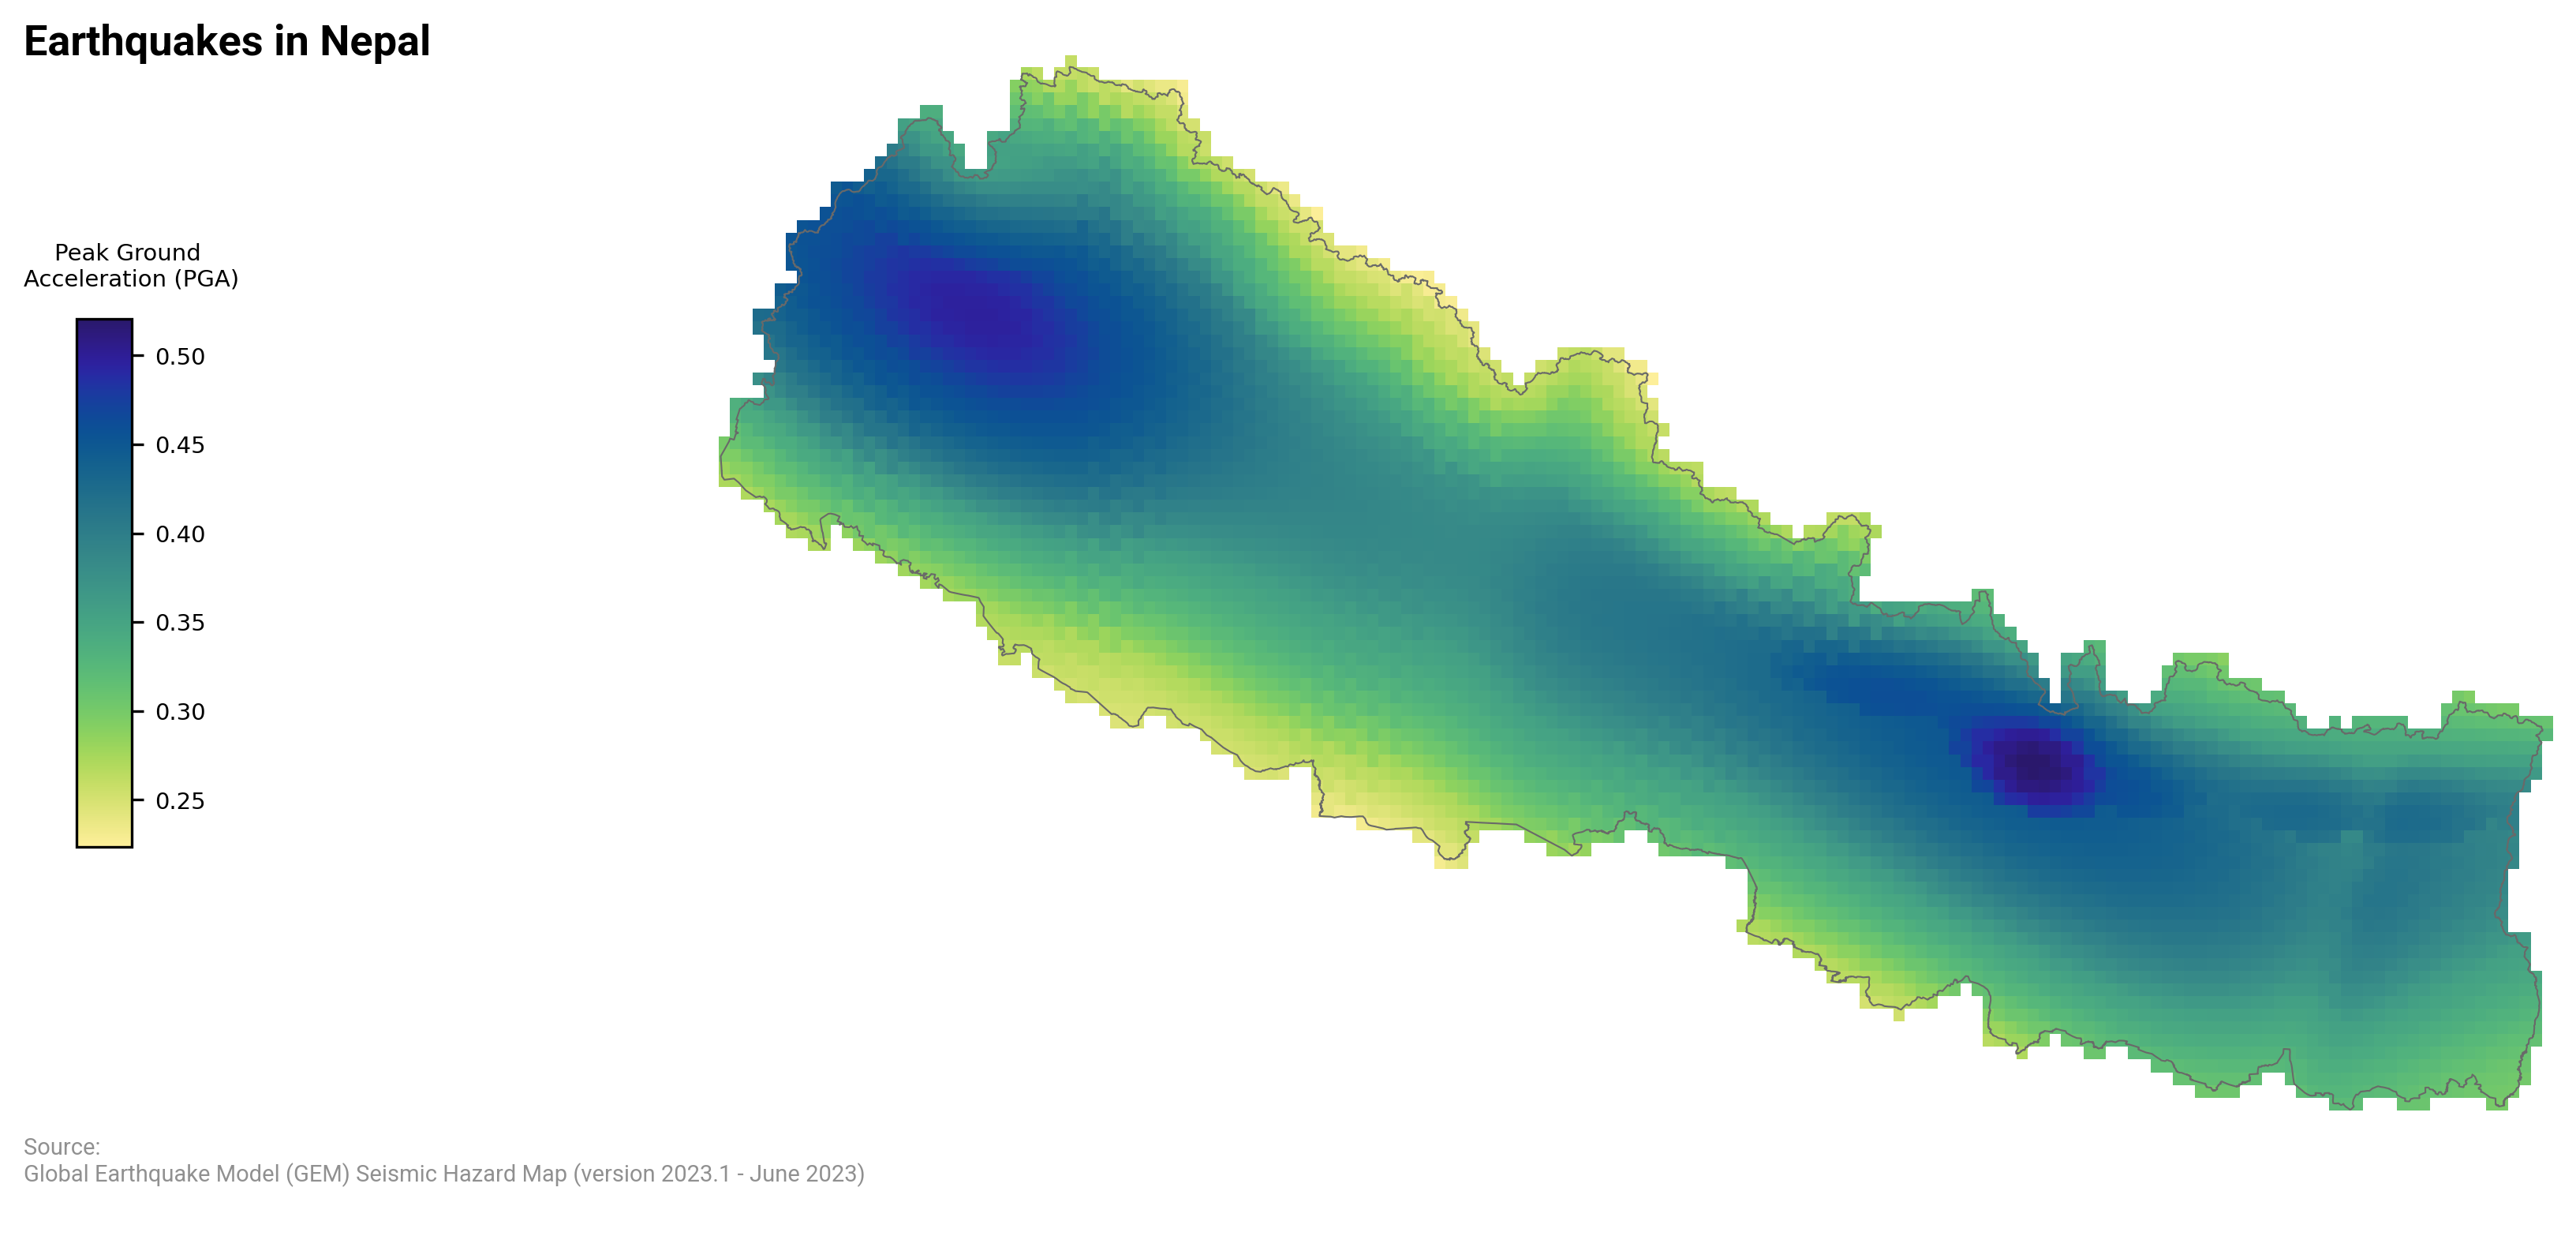

In [71]:
hazard = "earthquake" #"landslide_precip_gfdrr" # @param ["earthquake", "landslide_earthquake", "landslide_precip", "cyclone", "drought", "heat_stress", "fluvial_flood", "wildfire"]
ax = geoplot.plot_raster(hazard, save=True)
plt.show()

<a name="hazard-exposure"></a>
# Hazard Exposure

In [73]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    #map_mode="bivariate_choropleth",
    plot_hazard_exposure=True,
    #plot_conflict_exposure=True,
    out_dir="hazard_exposure"
)
widget.show()

Output()

In [36]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_hazard_exposure=True,
    out_dir="hazard_exposure"
)
widget.show()

Output()

<a name="multihazard-exposure-score"></a>
# Multihazard Exposure Score

In [37]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_mhs_exposure=True,
    out_dir="multihazard_exposure"
)
widget.show()

Output()

<a name="multihazard-conflict-exposure-score"></a>
# Multihazard-Conflict Exposure Score

In [38]:
widget = widgets.MapWidget(
    geoplot=geoplot,
    plot_conflict_exposure=True,
    plot_mhs_exposure=True,
    out_dir="conflict_events_multihazard_exposure"
)
widget.show()

Output()

## Bi-variate Choropleth Map

In [10]:
widget = widgets.MapWidget(
    map_mode="bivariate_choropleth",
    geoplot=geoplot,
    plot_conflict_exposure=True,
    plot_mhs_exposure=True,
    out_dir="multihazard_conflict_exposure"
)
widget.show()

Output()

<a name="interactive-mapping"></a>
# Interactive Mapping

In [ ]:
# @title Interactive Mapping with Folium
#geoplot.dm.data = dm.data
fmap = geoplot.plot_folium(
    adm_level=dm.adm_level,
    var="mhs_all_worldpop_exposure_relative",
    kwargs={"zoom_start": 7}
)
fmap = geoplot.plot_timestamped(
    dm.acled["worldpop"], fmap=fmap
)
fmap

In [ ]:
# @title Save Folium Map
fmap.save(f'{dm.iso_code}_folium_map.html')